In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import linear_model

In [2]:
df = pd.read_csv('used_cars.csv')
df

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"
...,...,...,...,...,...,...,...,...,...,...,...,...
4004,Bentley,Continental GT Speed,2023,714 mi.,Gasoline,6.0L W12 48V PDI DOHC Twin Turbo,8-Speed Automatic with Auto-Shift,C / C,Hotspur,None reported,Yes,"$349,950"
4005,Audi,S4 3.0T Premium Plus,2022,"10,900 mi.",Gasoline,349.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,"$53,900"
4006,Porsche,Taycan,2022,"2,116 mi.",NaN,Electric,Automatic,Black,Black,None reported,NaN,"$90,998"
4007,Ford,F-150 Raptor,2020,"33,000 mi.",Gasoline,450.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,A/T,Blue,Black,None reported,Yes,"$62,999"


In [3]:
#data cleaning

df['milage'] = df['milage'].astype(str).str.replace(r'[$,mi.]', '', regex=True)
df['price'] = df['price'].astype(str).str.replace(r'[$,]', '', regex=True)
#df['model_year'] = df['model_year'].astype(str).str.replace(r'[$,mi.]', '', regex=True)

df['milage'] = pd.to_numeric(df['milage'])
df['price'] = pd.to_numeric(df['price'])
#df['model_year'] = pd.to_numeric(df['model_year'])

display(df[['model_year' , 'price']])

,model_year,price
0,2013,10300
1,2021,38005
2,2022,54598
3,2015,15500
4,2021,34999
...,...,...
4004,2023,349950
4005,2022,53900
4006,2022,90998
4007,2020,62999


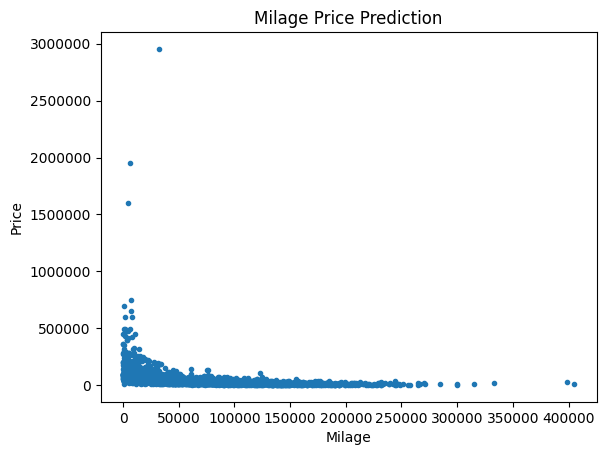

In [4]:
#visualization

plt.scatter(df['milage'], df['price'] , marker = '.')
plt.xlabel('Milage')
plt.ylabel('Price')
plt.title('Milage Price Prediction')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

In [5]:
#linear regression
reg = linear_model.LinearRegression()
reg = reg.fit(df[['milage']], df['price'])
reg

LinearRegression()

In [6]:
pred = reg.predict([[100000]])
x = pred
display('Price:' , x)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


'Price:'

array([28328.74693192])

In [7]:
reg.coef_

array([-0.45984459])

In [8]:
reg.intercept_

np.float64(74313.20621522398)

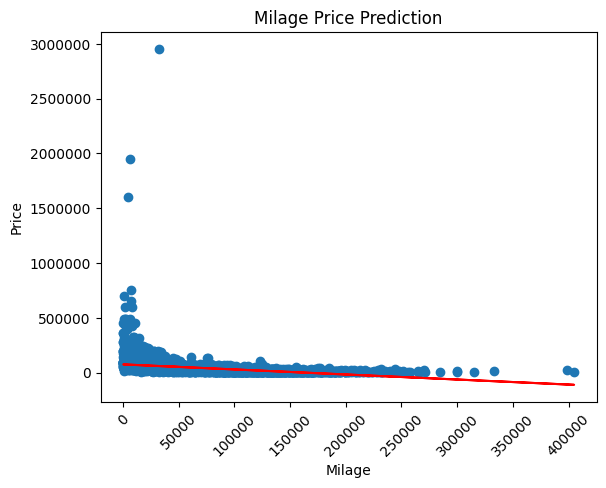

In [9]:
#visualize
plt.title('Milage Price Prediction')
plt.scatter(df['milage'], df['price'])
plt.plot(df['milage'], reg.predict(df[['milage']]), color='red')
plt.xlabel('Milage')
plt.ylabel('Price')
plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=45)
plt.show()

In [10]:
a = int(input("Enter milage:"))
pred = reg.predict([[a]])
print("Price:" + str(pred))

Enter milage:200000
Price:[-17655.71235138]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
